In [22]:
# --- BLOCK 1: IMPORTS, SETUP & DATA LOADING ---
import torch
import torchvision
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as T
import torchvision.transforms.functional as F
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
import os

# 1. CONSTANTS (ΟΙ 6 ΖΗΤΟΥΜΕΝΕΣ ΡΑΤΣΕΣ)
TARGET_BREEDS = [
    "Abyssinian", "Bengal", "Birman", "Boxer",
    "English Cocker Spaniel", "German Shorthaired"
]
NUM_CLASSES = 6
IMG_SIZE = (256, 256)
SEED = 42
BATCH_SIZE = 16
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"System Setup: Device={DEVICE}, Seed={SEED}")

# 2. CUSTOM DATASET WRAPPER
class FilteredPetDataset(Dataset):
    def __init__(self, root, split, target_breeds=None):
        self.base_dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types=("category", "segmentation"),
            download=True
        )
        self.target_breeds = target_breeds
        # We find the IDs
        self.breed_indices = [self.base_dataset.class_to_idx[b] for b in target_breeds]
        self.valid_indices = []
        
        # Keep the images that belong to the 6 classes!
        for idx, (_, (cls_idx, _)) in enumerate(self.base_dataset):
            if cls_idx in self.breed_indices:
                self.valid_indices.append(idx)

        print(f"Loading {split} dataset: Found {len(self.valid_indices)} images for 6 breeds.")

    def __len__(self):
        return len(self.valid_indices)

    def _remap_mask(self, mask):
        # 1=Foreground, 2=Background, 3=Border -> Target: 0=Bg, 1=Fg, 255=Ignore
        mask_np = np.array(mask)
        new_mask = np.zeros_like(mask_np)
        new_mask[mask_np == 2] = 0   # Background -> 0
        new_mask[mask_np == 1] = 1   # Foreground -> 1
        new_mask[mask_np == 3] = 255 # Border -> Ignore
        return torch.from_numpy(new_mask).long()

    def __getitem__(self, idx):
        real_idx = self.valid_indices[idx]
        image, (cls_idx, mask) = self.base_dataset[real_idx]

        # Resize 
        image = F.resize(image, IMG_SIZE, interpolation=F.InterpolationMode.BILINEAR)
        mask = F.resize(mask, IMG_SIZE, interpolation=F.InterpolationMode.NEAREST)

        image = F.to_tensor(image)
        mask = self._remap_mask(mask)

        # Initial ID (e.g. 35) to local ID (0-5)
        local_cls_idx = self.breed_indices.index(cls_idx)

        return image, local_cls_idx, mask

# 3. SPLIT & LOADERS
root_dir = "./data"
full_trainval = FilteredPetDataset(root_dir, "trainval", TARGET_BREEDS)
test_dataset = FilteredPetDataset(root_dir, "test", TARGET_BREEDS)

# Split 80/20 Train/Val
num_total = len(full_trainval)
num_train = int(0.8 * num_total)
num_val = num_total - num_train

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = torch.utils.data.random_split(
    full_trainval, [num_train, num_val], generator=generator
)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

System Setup: Device=cuda, Seed=42
Loading trainval dataset: Found 596 images for 6 breeds.
Loading test dataset: Found 597 images for 6 breeds.


In [23]:
# --- BLOCK 2: CLASSIC PIPELINE UTILITIES ---

# 1. MANUAL METRICS
def calculate_metrics(preds, targets, num_classes=6):
    preds = np.array(preds)
    targets = np.array(targets)
    correct = np.sum(preds == targets)
    accuracy = correct / len(targets) if len(targets) > 0 else 0
    
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for p, t in zip(preds, targets):
        if 0 <= t < num_classes and 0 <= p < num_classes:
            cm[t, p] += 1
    return accuracy, cm

# 2. FEATURE EXTRACTION (SIFT)
def extract_sift(loader, max_desc_per_img=None, mask_guided=False):
    sift = cv2.SIFT_create(contrastThreshold=0.03, edgeThreshold=10)
    all_des = []
    img_des = []
    labels = []
    
    dataset = loader.dataset
    indices = range(len(dataset)) # Access via indices mainly
    
    for i in indices:
        img, lbl, mask = dataset[i]
        
        img_np = (img.permute(1,2,0).numpy() * 255).astype(np.uint8)
        gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
        
        kp, des = sift.detectAndCompute(gray, None)
        
        # for the bonus BONUS: Mask Guided Logic
        if mask_guided and des is not None:
            mask_np = mask.numpy()
            valid_des = []
            for k, d in zip(kp, des):
                x, y = int(k.pt[0]), int(k.pt[1])
                # Border(255) OR Foreground(1) -> Keep
                if 0 <= y < 256 and 0 <= x < 256:
                    if mask_np[y,x] != 0: 
                        valid_des.append(d)
            des = np.array(valid_des) if valid_des else None

        if des is None or len(des) == 0:
            des = np.zeros((0, 128), dtype=np.float32)
            
        all_des.append(des)
        img_des.append(des)
        labels.append(lbl)
        
    return all_des, img_des, np.array(labels)

# 3. VOCABULARY BUILDING (K-Means)
def build_vocab(all_des_list, k=100, m_samples=40000):
    valid = [d for d in all_des_list if d.shape[0] > 0]
    if not valid: raise ValueError("No descriptors found!")
    
    stack = np.vstack(valid).astype(np.float32)
    
    if stack.shape[0] > m_samples:
        print(f"Sampling {m_samples} descriptors from {stack.shape[0]} total...")
        idx = np.random.choice(stack.shape[0], m_samples, replace=False)
        stack = stack[idx]
        
    print(f"Running K-Means (K={k})...")
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.1)
    _, _, centers = cv2.kmeans(stack, k, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    return centers

# 4. HISTOGRAM ENCODING (np.bincount implementation)
def encode_bof(img_des_list, vocab):
    k = vocab.shape[0]
    hists = []
    matcher = cv2.BFMatcher(cv2.NORM_L2)
    
    for des in img_des_list:
        if des is None or des.shape[0] == 0:
            h = np.zeros(k, dtype=np.float32)
        else:
            matches = matcher.match(des.astype(np.float32), vocab)
            # Use of bincount
            cluster_indices = np.array([m.trainIdx for m in matches])
            h = np.bincount(cluster_indices, minlength=k).astype(np.float32)
            
            # L1 Normalization
            if h.sum() > 0:
                h /= h.sum()
        hists.append(h)
    return np.array(hists)

In [24]:
# --- BLOCK 3: CNN ARCHITECTURE (U-Net) ---

class DoubleHeadUNet(nn.Module):
    def __init__(self, num_classes=6, dropout=0.2):
        super().__init__()
        
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True), 
                nn.Dropout(dropout)
            )
        
        # Encoder
        self.enc1 = block(3, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = block(16, 32)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = block(32, 64)
        
        # Classification Head
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.cls_fc = nn.Linear(64, num_classes) # returns logits
        
        # Decoder (Segmentation)
        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = block(64+32, 32)
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = block(32+16, 16)
        
        # Segmentation Head
        self.seg_conv = nn.Conv2d(16, 2, 1) # 2 Channels (Bg, Fg), Logits

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        b = self.bottleneck(p2)
        
        # Classification Path
        c = self.avg_pool(b).flatten(1)
        cls_out = self.cls_fc(c)
        
        # Segmentation Path
        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        seg_out = self.seg_conv(d1)
        
        return seg_out, cls_out

In [25]:
# --- BLOCK 4: TRAINING & LAMBDA TUNING ---

def calculate_global_iou(pred_mask, true_mask):
    valid = (true_mask != 255)
    pred = pred_mask[valid]
    true = true_mask[valid]
    
    inter = []
    union = []
    for c in range(2): # 0=Bg, 1=Fg
        p_inds = (pred == c)
        t_inds = (true == c)
        inter.append((p_inds & t_inds).sum().item())
        union.append((p_inds | t_inds).sum().item())
    return np.array(inter), np.array(union)

def train_cnn_epoch(model, loader, opt, crit_seg, crit_cls, lambda_val):
    model.train()
    total_loss = 0
    for img, lbl, mask in loader:
        img, lbl, mask = img.to(DEVICE), lbl.to(DEVICE), mask.to(DEVICE)
        opt.zero_grad()
        seg_out, cls_out = model(img)
        
        loss_seg = crit_seg(seg_out, mask)
        loss_cls = crit_cls(cls_out, lbl)
        # Cumulative Cost Func
        loss = (lambda_val * loss_seg) + loss_cls
        
        loss.backward()
        opt.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate_cnn(model, loader):
    model.eval()
    correct = 0
    total = 0
    g_inter = np.zeros(2)
    g_union = np.zeros(2)
    
    with torch.no_grad():
        for img, lbl, mask in loader:
            img, lbl, mask = img.to(DEVICE), lbl.to(DEVICE), mask.to(DEVICE)
            seg_out, cls_out = model(img)
            
            _, preds = torch.max(cls_out, 1)
            correct += (preds == lbl).sum().item()
            total += lbl.size(0)
            
            _, mask_preds = torch.max(seg_out, 1)
            i, u = calculate_global_iou(mask_preds, mask)
            g_inter += i
            g_union += u
            
    acc = correct / total
    miou = (g_inter / (g_union + 1e-6)).mean()
    return acc, miou

# --- MAIN LOOP TUNING ---
import copy 
lambda_candidates = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
best_cnn_acc = 0.0
best_lambda = None
best_cnn_model_weights = None 
best_cnn_hist = None

for lam in lambda_candidates:
    print(f"\nTraining with Lambda = {lam}...")
    model = DoubleHeadUNet(num_classes=6, dropout=0.2).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    crit_seg = nn.CrossEntropyLoss(ignore_index=255)
    crit_cls = nn.CrossEntropyLoss()
    
    history = {'loss': [], 'val_acc': [], 'val_miou': []}
    
    for ep in range(30):
        loss = train_cnn_epoch(model, train_loader, opt, crit_seg, crit_cls, lam)
        val_acc, val_miou = validate_cnn(model, val_loader)
        
        history['loss'].append(loss)
        history['val_acc'].append(val_acc)
        history['val_miou'].append(val_miou)

        print(f"  Ep {ep+1}: Loss={loss:.2f}, Val Acc={val_acc:.3f}, mIoU={val_miou:.3f}")
        
        # Check for best
        if val_acc > best_cnn_acc:
            best_cnn_acc = val_acc
            best_lambda = lam
            # keep copy of optimal weights
            best_cnn_model_weights = copy.deepcopy(model.state_dict())
            best_cnn_hist = copy.deepcopy(history)
            print(f"  -> NEW GLOBAL BEST saved at Ep {ep+1} (Acc={val_acc:.3f})")

# Load optimal weights 
best_cnn_model = DoubleHeadUNet(num_classes=6, dropout=0.2).to(DEVICE)
best_cnn_model.load_state_dict(best_cnn_model_weights)
print(f"\nFinal Selection: Best Lambda={best_lambda} with Peak Val Acc={best_cnn_acc:.3f}")


Training with Lambda = 0.5...
  Ep 1: Loss=2.08, Val Acc=0.133, mIoU=0.347
  -> NEW GLOBAL BEST saved at Ep 1 (Acc=0.133)
  Ep 2: Loss=1.94, Val Acc=0.242, mIoU=0.525
  -> NEW GLOBAL BEST saved at Ep 2 (Acc=0.242)
  Ep 3: Loss=1.90, Val Acc=0.292, mIoU=0.469
  -> NEW GLOBAL BEST saved at Ep 3 (Acc=0.292)
  Ep 4: Loss=1.87, Val Acc=0.267, mIoU=0.573
  Ep 5: Loss=1.85, Val Acc=0.342, mIoU=0.570
  -> NEW GLOBAL BEST saved at Ep 5 (Acc=0.342)
  Ep 6: Loss=1.82, Val Acc=0.267, mIoU=0.545
  Ep 7: Loss=1.82, Val Acc=0.192, mIoU=0.400
  Ep 8: Loss=1.81, Val Acc=0.300, mIoU=0.591
  Ep 9: Loss=1.80, Val Acc=0.275, mIoU=0.553
  Ep 10: Loss=1.78, Val Acc=0.292, mIoU=0.565
  Ep 11: Loss=1.76, Val Acc=0.217, mIoU=0.495
  Ep 12: Loss=1.74, Val Acc=0.325, mIoU=0.550
  Ep 13: Loss=1.74, Val Acc=0.325, mIoU=0.590
  Ep 14: Loss=1.73, Val Acc=0.200, mIoU=0.478
  Ep 15: Loss=1.70, Val Acc=0.300, mIoU=0.512
  Ep 16: Loss=1.68, Val Acc=0.250, mIoU=0.494
  Ep 17: Loss=1.68, Val Acc=0.292, mIoU=0.564
  Ep 18:

In [34]:
# --- BLOCK 5: TRADITIONAL PIPELINE & K TUNING (UPDATED) ---
from torch.utils.data import TensorDataset

# 1. Extract SIFT once
print("Extracting SIFT Features (Full Set)...")
train_all_des, train_img_des, train_y = extract_sift(train_loader)
val_all_des, val_img_des, val_y = extract_sift(val_loader)
test_all_des, test_img_des, test_y = extract_sift(test_loader)

class ShallowMLP(nn.Module):
    def __init__(self, input_dim, num_classes=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), 
            nn.ReLU(), 
            nn.Dropout(0.3),
            nn.Linear(256, 128), 
            nn.ReLU(), 
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.net(x)

def train_mlp_pipeline(k_vals=[300, 400, 500]):
    best_acc = 0
    best_k = 0
    best_model = None
    best_vocab = None
    best_mlp_hist = None  # Store history of the best K
    
    for k in k_vals:
        print(f"\n--- Testing K={k} ---")
        vocab = build_vocab(train_all_des, k=k, m_samples=40000)
        
        X_train = torch.tensor(encode_bof(train_img_des, vocab)).float()
        y_train = torch.tensor(train_y).long()
        X_val = torch.tensor(encode_bof(val_img_des, vocab)).float()
        y_val = torch.tensor(val_y).long()
        
        mlp = ShallowMLP(k, num_classes=6).to(DEVICE)
        opt = optim.Adam(mlp.parameters(), lr=0.001, weight_decay=1e-4)
        crit = nn.CrossEntropyLoss()
        
        train_ds = TensorDataset(X_train, y_train)
        train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
        
        # Local history for this K
        history = {'loss': [], 'val_acc': []}
        curr_best_val = 0
        
        for ep in range(30):
            mlp.train()
            total_loss = 0
            for xb, yb in train_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = crit(mlp(xb), yb)
                loss.backward()
                opt.step()
                total_loss += loss.item()
                
            # Validation
            mlp.eval()
            with torch.no_grad():
                out = mlp(X_val.to(DEVICE))
                acc = (out.argmax(1).cpu() == y_val).float().mean().item()
            
            # Save metrics
            history['loss'].append(total_loss / len(train_dl))
            history['val_acc'].append(acc)
            
            if acc > curr_best_val: curr_best_val = acc
            
        print(f"K={k} Best Val Acc: {curr_best_val:.3f}")
        
        # Check if this K is the global best
        if curr_best_val > best_acc:
            best_acc = curr_best_val
            best_k = k
            best_model = mlp
            best_vocab = vocab
            best_mlp_hist = history # Keep this history
            
    return best_k, best_model, best_vocab, best_acc, best_mlp_hist

# Execute
best_k, mlp_model, vocab, mlp_val_acc, best_mlp_hist = train_mlp_pipeline()
print(f"\nBest Traditional Model: K={best_k} (Val Acc={mlp_val_acc:.3f})")

Extracting SIFT Features (Full Set)...

--- Testing K=300 ---
Sampling 40000 descriptors from 254117 total...
Running K-Means (K=300)...
K=300 Best Val Acc: 0.367

--- Testing K=400 ---
Sampling 40000 descriptors from 254117 total...
Running K-Means (K=400)...
K=400 Best Val Acc: 0.367

--- Testing K=500 ---
Sampling 40000 descriptors from 254117 total...
Running K-Means (K=500)...
K=500 Best Val Acc: 0.367

Best Traditional Model: K=300 (Val Acc=0.367)


In [35]:
# --- BLOCK 6: ROBUSTNESS CHECK ---

class NoisyBgDataset(Dataset):
    def __init__(self, orig_dataset):
        self.orig = orig_dataset
    def __len__(self): return len(self.orig)
    def __getitem__(self, idx):
        img, lbl, mask = self.orig[idx]
        mask_np = np.array(mask)
        binary_mask = np.zeros_like(mask_np, dtype=np.uint8)
        binary_mask[mask_np != 0] = 255 
        
        img_perm = img.permute(1, 2, 0).numpy()
        img_uint8 = (img_perm * 255).astype(np.uint8)
        img_uint8 = np.ascontiguousarray(img_uint8)
        
        noise = np.zeros(img_uint8.shape, dtype=np.uint8)
        cv2.randu(noise, (0,0,0), (255,255,255))
        noise_blur = cv2.GaussianBlur(noise, (21,21), 0)
        
        fg = cv2.bitwise_and(img_uint8, img_uint8, mask=binary_mask)
        mask_inv = cv2.bitwise_not(binary_mask)
        bg = cv2.bitwise_and(noise_blur, noise_blur, mask=mask_inv)
        combined = cv2.add(fg, bg)
        
        return F.to_tensor(combined), lbl, mask

noisy_loader = DataLoader(NoisyBgDataset(test_dataset), batch_size=BATCH_SIZE)

best_cnn_model.eval()
cnn_correct = 0
with torch.no_grad():
    for img, lbl, _ in noisy_loader:
        _, out = best_cnn_model(img.to(DEVICE))
        cnn_correct += (out.argmax(1) == lbl.to(DEVICE)).sum().item()
cnn_noisy_acc = cnn_correct / len(test_dataset)

n_all, n_img, n_y = extract_sift(noisy_loader)
X_noisy = torch.tensor(encode_bof(n_img, vocab)).float().to(DEVICE)
mlp_model.eval()
with torch.no_grad():
    out = mlp_model(X_noisy)
    mlp_noisy_acc = (out.argmax(1).cpu() == torch.tensor(n_y)).float().mean().item()

print(f"Robustness Results:\nCNN Noisy Acc: {cnn_noisy_acc:.3f}\nMLP Noisy Acc: {mlp_noisy_acc:.3f}")

Robustness Results:
CNN Noisy Acc: 0.317
MLP Noisy Acc: 0.348


In [36]:
# --- BLOCK 7: BONUS PART IMPLEMENTATION (MASK-GUIDED VOCAB) ---
print("\n--- BONUS: Mask-Guided Experiments ---")
print("Building FG-Only Vocabulary...")
train_fg_all, train_fg_des, _ = extract_sift(train_loader, mask_guided=True)
fg_vocab = build_vocab(train_fg_all, k=best_k, m_samples=40000)

def train_mlp_experiment(X_train, y_train, X_test, y_test):
    mlp = ShallowMLP(best_k).to(DEVICE)
    opt = optim.Adam(mlp.parameters(), lr=0.001, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    train_ds = TensorDataset(X_train, y_train)
    train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
    
    for ep in range(30):
        mlp.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(mlp(xb), yb)
            loss.backward()
            opt.step()
    
    mlp.eval()
    with torch.no_grad():
        out = mlp(X_test.to(DEVICE))
        acc = (out.argmax(1).cpu() == y_test).float().mean().item()
    return acc

y_tr_t = torch.tensor(train_y).long()
y_te_t = torch.tensor(test_y).long()

X_tr_1 = torch.tensor(encode_bof(train_img_des, fg_vocab)).float()
X_te_1 = torch.tensor(encode_bof(test_img_des, fg_vocab)).float()
acc_exp1 = train_mlp_experiment(X_tr_1, y_tr_t, X_te_1, y_te_t)

X_tr_2 = torch.tensor(encode_bof(train_fg_des, fg_vocab)).float()
acc_exp2 = train_mlp_experiment(X_tr_2, y_tr_t, X_te_1, y_te_t)


--- BONUS: Mask-Guided Experiments ---
Building FG-Only Vocabulary...
Sampling 40000 descriptors from 137109 total...
Running K-Means (K=300)...


Generating Final Report Data...

--- 1. CNN TRAINING CURVES ---


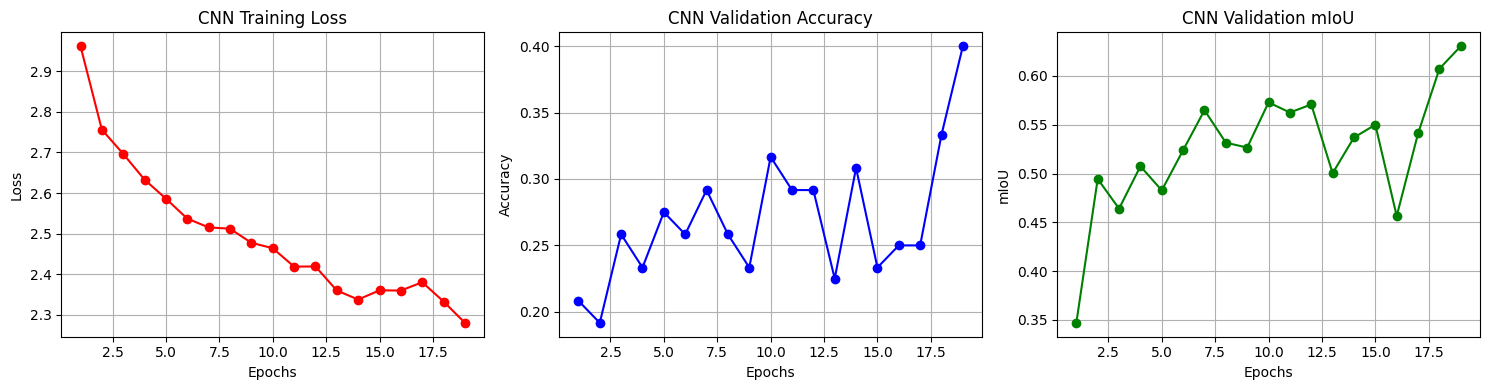


--- 2. MLP TRAINING CURVES (Best K) ---


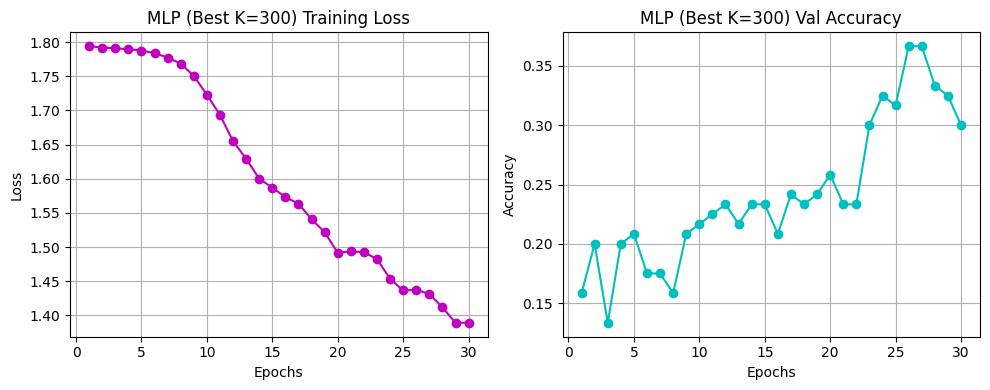


--- 3. CONFUSION MATRICES (CNN vs MLP) ---


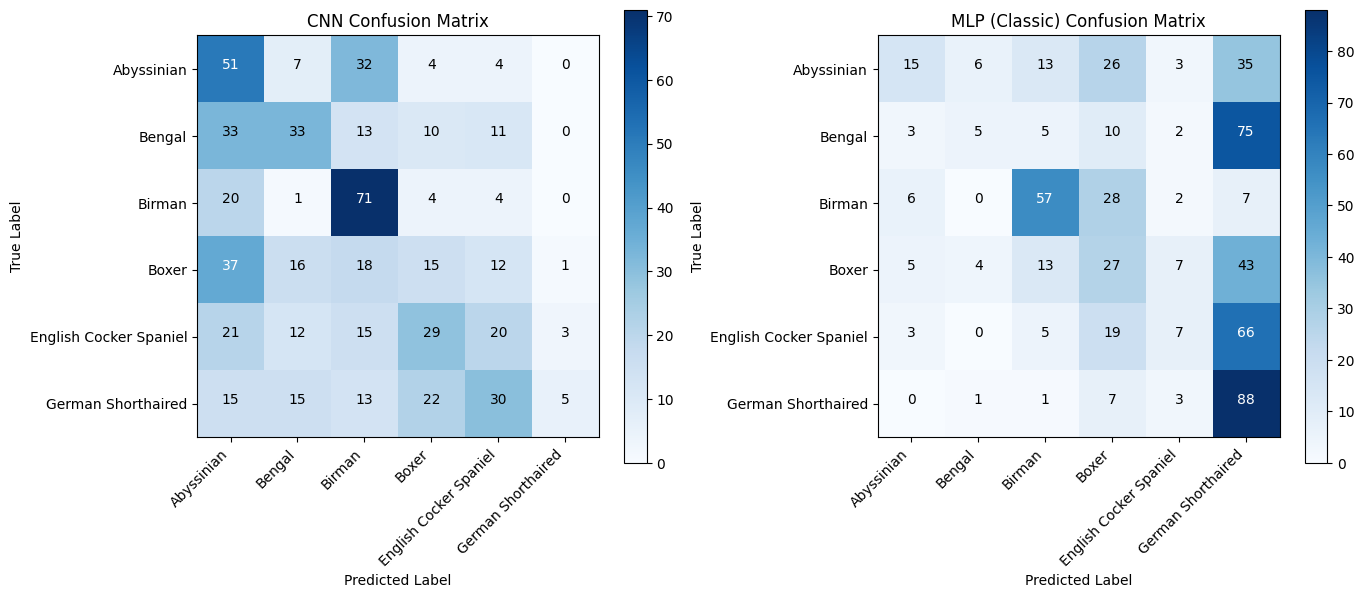


--- 4. METHOD COMPARISON (ACCURACY) ---


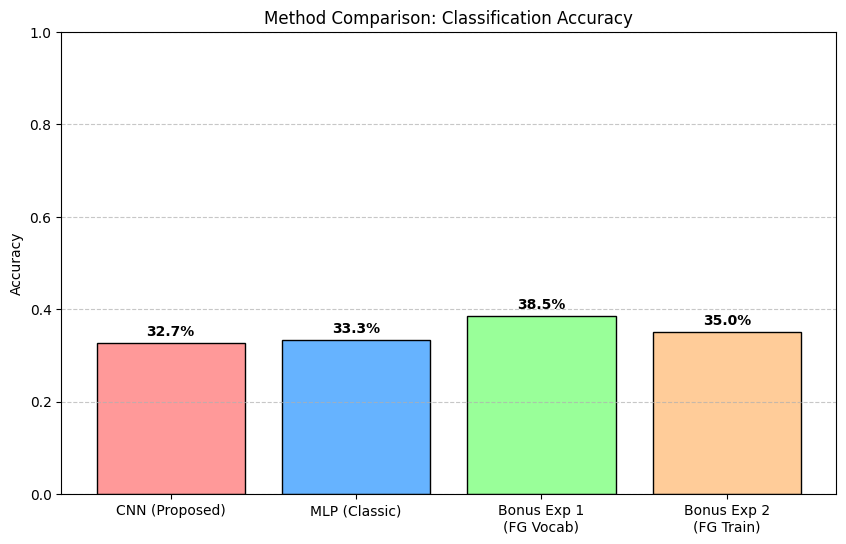


--- 5. QUALITATIVE SEGMENTATION RESULTS ---


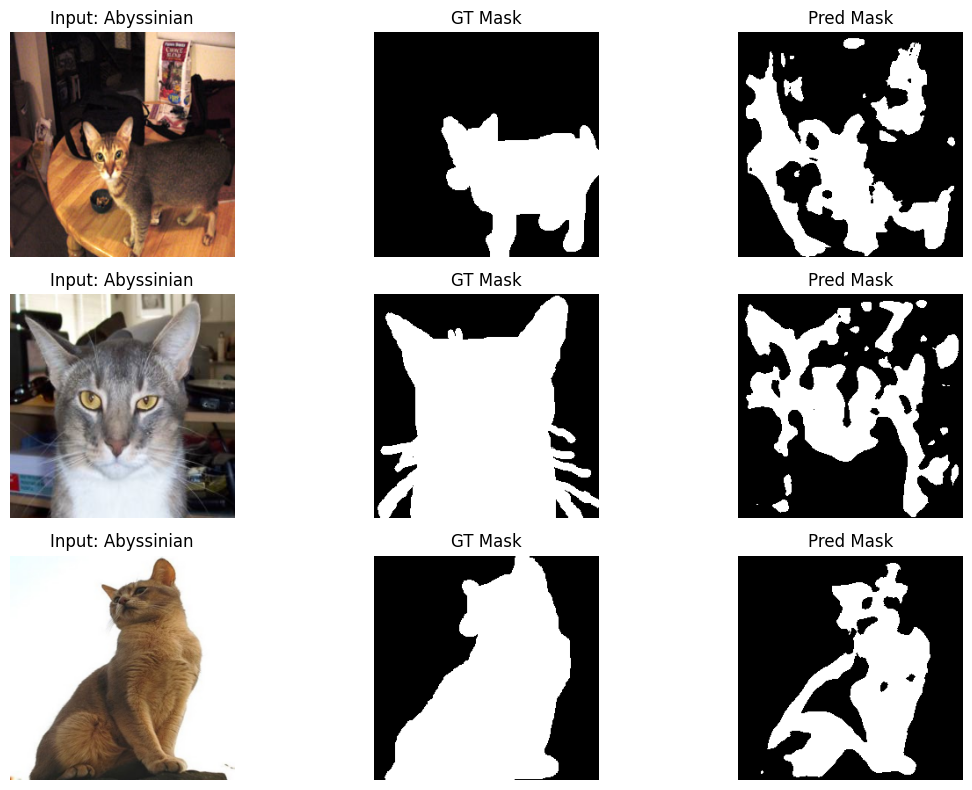

In [37]:
# --- BLOCK 8: FINAL RESULTS & VISUALIZATIONS (SAVES IMAGES) ---
# Requirements: Metrics, Confusion Matrix, Qualitative Results, ALL Hyperparameters, ALL PLOTS

def get_predictions(model, loader, is_mlp=False, vocab=None):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        if is_mlp:
            des_list, img_des, y_labels = extract_sift(loader) 
            X = torch.tensor(encode_bof(img_des, vocab)).float().to(DEVICE)
            out = model(X)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(y_labels)
        else:
            for img, lbl, _ in loader:
                img = img.to(DEVICE)
                _, cls_out = model(img)
                preds = cls_out.argmax(1).cpu().numpy()
                all_preds.extend(preds)
                all_targets.extend(lbl.numpy())
    return np.array(all_preds), np.array(all_targets)

# 1. GENERATE PREDICTIONS
print("Generating Final Report Data...")
cnn_preds, cnn_targets = get_predictions(best_cnn_model, test_loader, is_mlp=False)
mlp_preds, mlp_targets = get_predictions(mlp_model, test_loader, is_mlp=True, vocab=vocab)

_, cnn_cm = calculate_metrics(cnn_preds, cnn_targets)
_, mlp_cm = calculate_metrics(mlp_preds, mlp_targets)

# --- VISUALIZATION FUNCTIONS (WITH SAVING) ---

def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, ha="right")
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

def plot_cnn_curves(history):
    loss = history['loss']
    acc = history['val_acc']
    miou = history['val_miou']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(15, 4))
    
    plt.subplot(1, 3, 1)
    plt.plot(epochs, loss, 'r-o', label='Train Loss')
    plt.title('CNN Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, acc, 'b-o', label='Val Accuracy')
    plt.title('CNN Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, miou, 'g-o', label='Val mIoU')
    plt.title('CNN Validation mIoU')
    plt.xlabel('Epochs')
    plt.ylabel('mIoU')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('cnn_curves.png') # SAVE
    plt.show()

def plot_mlp_curves(history):
    loss = history['loss']
    acc = history['val_acc']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'm-o', label='Train Loss')
    plt.title(f'MLP (Best K={best_k}) Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'c-o', label='Val Accuracy')
    plt.title(f'MLP (Best K={best_k}) Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig('mlp_curves.png') # SAVE
    plt.show()

def plot_method_comparison(cnn_acc, mlp_acc, exp1_acc, exp2_acc):
    methods = ['CNN (Proposed)', 'MLP (Classic)', 'Bonus Exp 1\n(FG Vocab)', 'Bonus Exp 2\n(FG Train)']
    accuracies = [cnn_acc, mlp_acc, exp1_acc, exp2_acc]
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

    plt.figure(figsize=(10, 6))
    bars = plt.bar(methods, accuracies, color=colors, edgecolor='black')
    
    plt.ylabel('Accuracy')
    plt.title('Method Comparison: Classification Accuracy')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.1%}", ha='center', va='bottom', fontweight='bold')
    
    plt.savefig('method_comparison.png') # SAVE
    plt.show()

def show_qualitative_results(model, loader):
    model.eval()
    iter_loader = iter(loader)
    plt.figure(figsize=(12, 8))
    
    with torch.no_grad():
        for i in range(3):
            try: img, lbl, mask = next(iter_loader)
            except StopIteration: break
            
            img = img.to(DEVICE)
            seg_out, _ = model(img)
            _, pred_mask = torch.max(seg_out, 1)
            
            img_np = img[0].cpu().permute(1, 2, 0).numpy()
            true_mask = mask[0].cpu().numpy()
            pred_mask = pred_mask[0].cpu().numpy()
            
            plt.subplot(3, 3, i*3 + 1)
            plt.imshow(img_np)
            plt.title(f"Input: {TARGET_BREEDS[lbl[0]]}")
            plt.axis('off')
            plt.subplot(3, 3, i*3 + 2)
            plt.imshow(true_mask, cmap='gray', vmin=0, vmax=1)
            plt.title("GT Mask")
            plt.axis('off')
            plt.subplot(3, 3, i*3 + 3)
            plt.imshow(pred_mask, cmap='gray', vmin=0, vmax=1)
            plt.title("Pred Mask")
            plt.axis('off')
    plt.tight_layout()
    plt.savefig('qualitative_results.png') # SAVE
    plt.show()

# --- EXECUTE VISUALIZATIONS ---

print("\n--- 1. CNN TRAINING CURVES ---")
if best_cnn_hist:
    plot_cnn_curves(best_cnn_hist)

print("\n--- 2. MLP TRAINING CURVES (Best K) ---")
if best_mlp_hist:
    plot_mlp_curves(best_mlp_hist)
else:
    print("Run Block 5 again to capture MLP history!")

print("\n--- 3. CONFUSION MATRICES (CNN vs MLP) ---")
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plot_confusion_matrix(cnn_cm, TARGET_BREEDS, title="CNN Confusion Matrix")
plt.subplot(1, 2, 2)
plot_confusion_matrix(mlp_cm, TARGET_BREEDS, title="MLP (Classic) Confusion Matrix")
plt.tight_layout()
plt.savefig('confusion_matrices.png') # SAVE
plt.show()

print("\n--- 4. METHOD COMPARISON (ACCURACY) ---")
acc_cnn = (cnn_preds==cnn_targets).mean()
acc_mlp = (mlp_preds==mlp_targets).mean()
plot_method_comparison(acc_cnn, acc_mlp, acc_exp1, acc_exp2)

print("\n--- 5. QUALITATIVE SEGMENTATION RESULTS ---")
show_qualitative_results(best_cnn_model, test_loader)

In [41]:
# --- BLOCK 9: GENERATE REPORT MARKDOWN ---
# Run this to get a clean text block to copy-paste into your report

cnn_test_acc = (cnn_preds==cnn_targets).mean()
mlp_test_acc = (mlp_preds==mlp_targets).mean()

report_markdown = f"""
================================================================================
                        FINAL REPORT RESULTS (COPY BELOW)
================================================================================

### 1. Hyperparameters & Protocol
* **Seed:** {SEED}
* **Batch Size:** {BATCH_SIZE}
* **Optimizer:** Adam (lr=0.001, weight_decay=1e-4)
* **CNN Training:**
    * Epochs: 30 (Fixed)
    * Best Lambda (Found): {best_lambda}
    * Dropout: 0.2
* **MLP Training:**
    * Feature Extractor: SIFT (ContrastThreshold=0.03)
    * Dictionary Size (M): 40,000
    * Best K (Visual Words): {best_k}
    * Structure: Input -> 256 -> 128 -> 6 (Dropout 0.3/0.2)

### 2. Quantitative Results
| Method | Test Accuracy (CCR) | mIoU (Segmentation) | Robustness Acc (Noisy Bg) |
| :--- | :---: | :---: | :---: |
| **CNN (Proposed)** | **{cnn_test_acc:.4f}** | **{best_cnn_hist['val_miou'][-1]:.4f}** | {cnn_noisy_acc:.4f} |
| **MLP (Classic)** | **{mlp_test_acc:.4f}** | N/A | {mlp_noisy_acc:.4f} |

### 3. Training Curves
**CNN Learning Curves:**
![CNN Curves](cnn_curves.png)

**MLP Learning Curves:**
![MLP Curves](mlp_curves.png)

### 4. Method Comparison
**Accuracy Comparison Bar Chart:**
![Comparison](method_comparison.png)

### 5. Confusion Matrices
**Left: CNN | Right: MLP**
![Confusion Matrices](confusion_matrices.png)

### 6. Qualitative Segmentation
**Sample Predictions on Test Set:**
![Qualitative Results](qualitative_results.png)

### 7. Bonus Experiments (Mask-Guided SIFT)
| Experiment | Description | Test Accuracy |
| :--- | :--- | :---: |
| **Bonus Exp 1** | Foreground Vocab + Full Image Encoding | {acc_exp1:.4f} |
| **Bonus Exp 2** | Foreground Vocab + Foreground-Only Train Encoding | {acc_exp2:.4f} |

**Raw Confusion Matrix Data (CNN):**
{cnn_cm}

**Raw Confusion Matrix Data (MLP):**
{mlp_cm}
================================================================================
"""

print(report_markdown)


                        FINAL REPORT RESULTS (COPY BELOW)

### 1. Hyperparameters & Protocol
* **Seed:** 42
* **Batch Size:** 16
* **Optimizer:** Adam (lr=0.001, weight_decay=1e-4)
* **CNN Training:**
    * Epochs: 30 (Fixed)
    * Best Lambda (Found): 2.0
    * Dropout: 0.2
* **MLP Training:**
    * Feature Extractor: SIFT (ContrastThreshold=0.03)
    * Dictionary Size (M): 40,000
    * Best K (Visual Words): 300
    * Structure: Input -> 256 -> 128 -> 6 (Dropout 0.3/0.2)

### 2. Quantitative Results
| Method | Test Accuracy (CCR) | mIoU (Segmentation) | Robustness Acc (Noisy Bg) |
| :--- | :---: | :---: | :---: |
| **CNN (Proposed)** | **0.3266** | **0.6306** | 0.3166 |
| **MLP (Classic)** | **0.3333** | N/A | 0.3484 |

### 3. Training Curves
**CNN Learning Curves:**
![CNN Curves](cnn_curves.png)

**MLP Learning Curves:**
![MLP Curves](mlp_curves.png)

### 4. Method Comparison
**Accuracy Comparison Bar Chart:**
![Comparison](method_comparison.png)

### 5. Confusion Matrices
**Left: 